In [1]:
import pandas as pd
from seismostats import Catalog
import matplotlib.pyplot as plt
import numpy as np
import warnings

## get data

In [2]:
# ML high resoution catalog

location = 'data/catalogs/Amatrice_CAT5.v20210325'

cat_raw = pd.read_csv(location, 
                 sep=r"\s+",
                 header=None,
                 skiprows=22,)

column_names = [
    "year", "month", "day", "hour", "minute", "second",
    "latitude", "longitude", "depth",
    "EH1", "EH2", "AZ", "EZ",
    "ML", "Mw",
    "ID"
]

cat_raw.columns = column_names

cat_all = cat_raw.copy()
cat_all['time'] = pd.to_datetime(cat_all[['year', 'month', 'day', 'hour', 'minute', 'second']])
cat_all['magnitude'] = cat_all['ML']
# delete the time columns
cat_all.drop(columns=['year', 'month', 'day', 'hour', 'minute', 'second'], inplace=True)

In [37]:
cat_all = Catalog(cat_all)

<Axes: xlabel='Time', ylabel='Magnitude'>

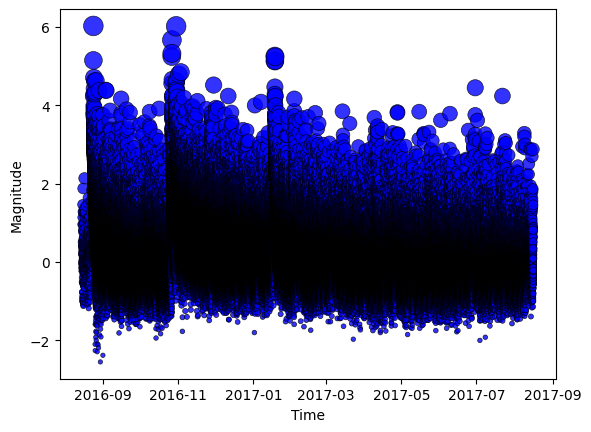

In [38]:
cat_all.plot_mags_in_time()

## filter, binnin, data cleaning

In [39]:
# test binning
from seismostats.utils import binning_test
print(binning_test(cat_all.magnitude.values, delta_x=0.01))
delta_m = 0.01
cat_all.delta_m = delta_m


True


In [41]:
# remove nonan
cat_all = cat_all[~cat_all['magnitude'].isna()]

# remove events deeper than 50 km
cat_all = cat_all[cat_all['depth'] <= 50]

cat_all = cat_all[cat_all.latitude <= 43.1]
cat_all = cat_all[cat_all.latitude >= 42.5]
cat_all = cat_all[cat_all.longitude >= 12.9]
cat_all = cat_all[cat_all.longitude <= 13.4]


In [42]:
# sort df_amatrice in time
cat_all = cat_all.sort_values(by='time')

# 60% train
cat_train = cat_all.copy()
cat_train = cat_train.iloc[:int(0.6*len(cat_train))]

# 40% test
cat_test = cat_all.copy()
cat_test = cat_test.iloc[int(0.6*len(cat_test)):]


<Axes: xlabel='Time', ylabel='Magnitude'>

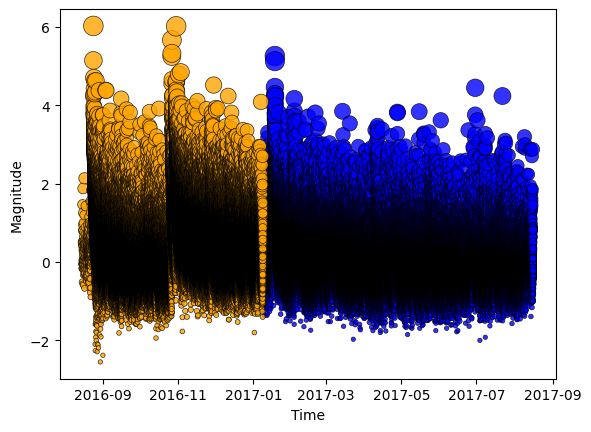

In [43]:
ax = cat_test.plot_mags_in_time()
cat_train.plot_mags_in_time(ax=ax, color_dots='orange')

## transform and rotate

In [44]:
from functions.transformation_functions import transform_and_rotate
p1 = np.array([42.8, 13.0, 0])
p2 = np.array([42.8, 13.2, 0])

In [45]:
# transform and rotate cat_all
lats = cat_all['latitude'].values
lons = cat_all['longitude'].values
depths = cat_all['depth'].values

cart_coords, cart_p2 = transform_and_rotate(p1, p2, lats, lons, depths)

cat_all['x'] = cart_coords[1, :]
cat_all['y'] = cart_coords[0, :]
cat_all['z'] = cart_coords[2, :]

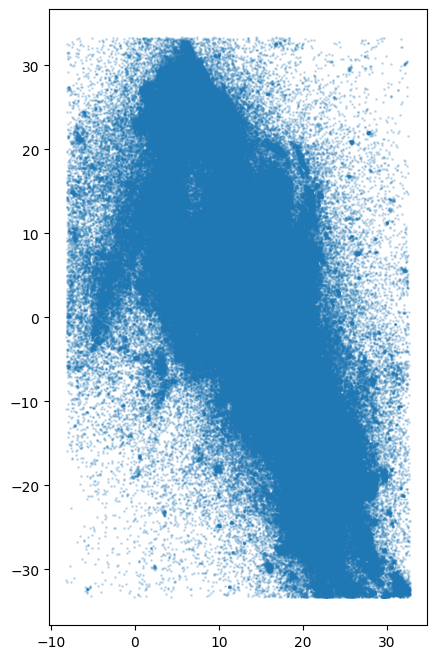

In [46]:
import numpy as np

# make ax cartopy geoaxis
import cartopy.crs as ccrs
fig = plt.figure(figsize=(12, 8))
plt.scatter(cat_all.y, cat_all.x, s=1, alpha=0.2)

#equal axis
plt.gca().set_aspect('equal', adjustable='box')

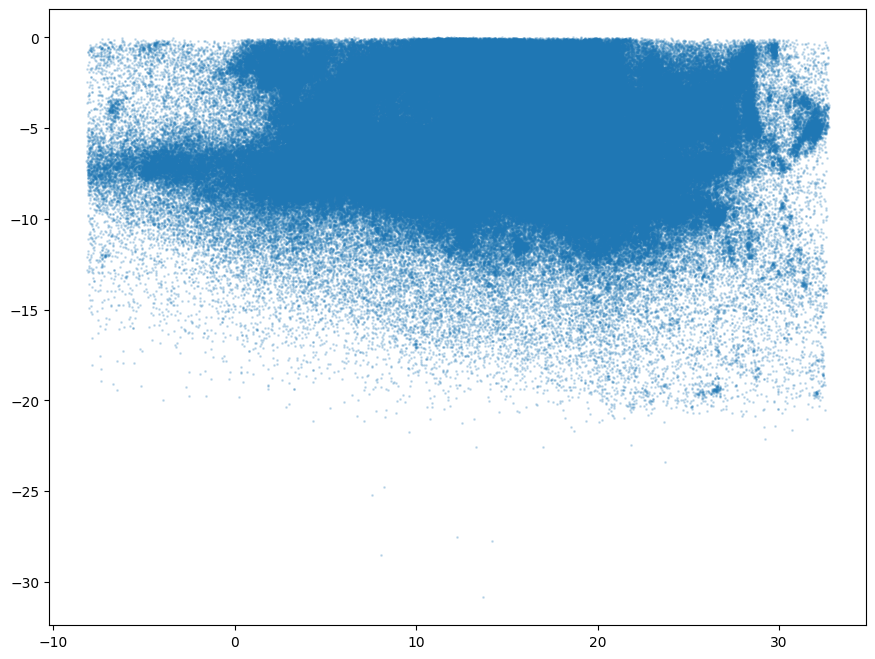

In [47]:
import numpy as np

# make ax cartopy geoaxis
import cartopy.crs as ccrs
fig = plt.figure(figsize=(12, 8))
plt.scatter(cat_all.y, cat_all.z, s=1, alpha=0.2)

#equal axis
plt.gca().set_aspect('equal', adjustable='box')